# Biomass Prediction Dataset Analysis & LTN Feasibility Study

## Section 0: Project Overview

### Dataset Purpose

This dataset is designed to predict pasture biomass using a multimodal approach. In precision agriculture, accurately estimating biomass is crucial for pasture management, yield prediction, and resource allocation. Traditional methods are destructive and labor-intensive.

### The Multi-Modal Approach

- **Images:** Capture the visual structure, color, density, and texture of the pasture, which are strong visual proxies for biomass.
- **Metadata:** Provides structured context (NDVI, height, species, temporal, and spatial data) that grounds the visual features in physical reality.

### Logical Tensor Networks (LTNs) and Constraints

The core research question is whether an LTN can improve model performance. Standard Neural Networks predict targets independently. LTNs inject domain knowledge by heavily penalizing predictions that violate known physical laws.

For this dataset, we predict 5 target variables (`Dry_Clover_g`, `Dry_Dead_g`, `Dry_Green_g`, `Dry_Total_g`, `GDM_g`) governed by two strict logical constraints:

**Total Biomass Equation:**
$$\text{Dry\_Total\_g} = \text{Dry\_Clover\_g} + \text{Dry\_Dead\_g} + \text{Dry\_Green\_g}$$

**Green Dry Matter (GDM) Equation:**
$$\text{GDM\_g} = \text{Dry\_Clover\_g} + \text{Dry\_Green\_g}$$

This notebook will investigate the dataset structure, feature importance, baseline predictivity, and crucially, whether these logical constraints are already perfectly satisfied in the ground truth data.

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import cv2
from PIL import Image
import os
from tqdm.notebook import tqdm
import plotly.express as px
import umap
import shap
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

# Set clean plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
tqdm.pandas()

# Define dataset paths (Update these if your paths differ)
CSV_PATH = 'train.csv'
IMAGE_DIR = './Images' # Assuming images are extracted in the same directory or a subfolder

## Section 1: Load Dataset

**Explanation:** We begin by loading the `train.csv` file to understand the high-level schema, data types, and basic statistics.

**Interpretation Instructions:** Look at the total rows vs. unique images. If the row count is exactly 5 times the unique image count, the dataset is perfectly structured in a "long" format. Check the `describe()` output for any obvious anomalies (e.g., negative targets).

In [4]:
# Load the dataset
df = pd.read_csv(CSV_PATH)

print(f"Dataset Shape: {df.shape}")
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"Unique Images: {df['image_path'].nunique()}")
print(f"Unique Target Types: {df['target_name'].nunique()}")

display(df.head())
display(df.info())
display(df.describe())

Dataset Shape: (1785, 9)
Total Rows: 1785
Total Columns: 9
Unique Images: 357
Unique Target Types: 5


,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1785 entries, 0 to 1784
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_id      1785 non-null   object 
 1   image_path     1785 non-null   object 
 2   Sampling_Date  1785 non-null   object 
 3   State          1785 non-null   object 
 4   Species        1785 non-null   object 
 5   Pre_GSHH_NDVI  1785 non-null   float64
 6   Height_Ave_cm  1785 non-null   float64
 7   target_name    1785 non-null   object 
 8   target         1785 non-null   float64
dtypes: float64(3), object(6)
memory usage: 125.6+ KB


None

,Pre_GSHH_NDVI,Height_Ave_cm,target
count,1785.000000,1785.000000,1785.000000
mean,0.657423,7.595985,24.782295
std,0.151972,10.273725,25.823738
min,0.160000,1.000000,0.000000
25%,0.560000,3.000000,4.818200
50%,0.690000,4.000000,18.200000
75%,0.770000,7.000000,35.940600
max,0.910000,70.000000,185.700000


### Conclusions (Section 1):

Record your observations here.
- **Expected:** The dataset is in long format.
- **Expected:** `target` should have a minimum value $\geq 0$.

## Section 2: Dataset Structure Investigation

**Explanation:** We need to confirm how `target_name` and `target` are organized per image. We will visualize the distribution of target types and check for incomplete data blocks (e.g., an image missing a `GDM_g` row).

Images with exactly 5 rows: 357
Images with != 5 rows: 0


C:\Users\HP\AppData\Local\Temp\ipykernel_9936\2885042922.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target_name', palette='viridis')


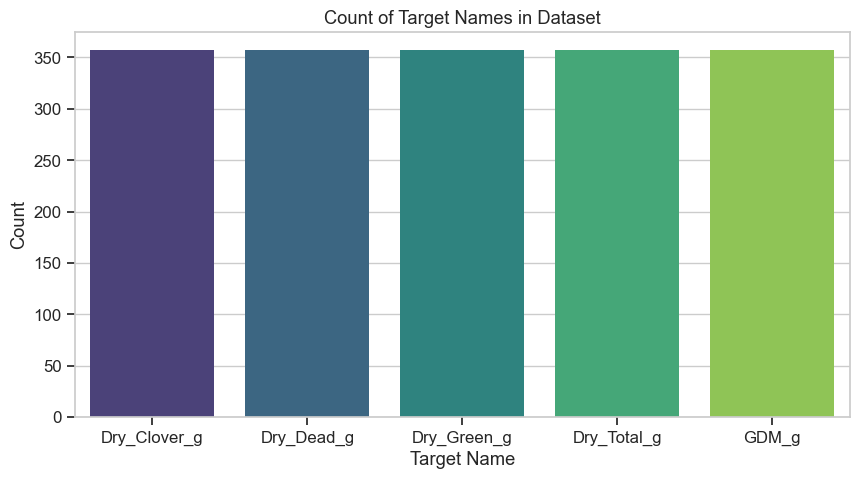

Duplicate target entries per image: 0


In [5]:
# Check rows per image
rows_per_image = df.groupby('image_path').size()
print(f"Images with exactly 5 rows: {(rows_per_image == 5).sum()}")
print(f"Images with != 5 rows: {(rows_per_image != 5).sum()}")

# Target distribution counts
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='target_name', palette='viridis')
plt.title('Count of Target Names in Dataset')
plt.ylabel('Count')
plt.xlabel('Target Name')
plt.show()

# Check for duplicated target_names per image
duplicates = df.duplicated(subset=['image_path', 'target_name']).sum()
print(f"Duplicate target entries per image: {duplicates}")

### Conclusions (Section 2):

If all target names have equal counts and no duplicates exist per image, the dataset is perfectly uniform, and every image is guaranteed to have all 5 target variables.

## Section 3: Convert Dataset into Wide Format

**Explanation:** The "long" format (one row per target) is excellent for databases but terrible for Machine Learning models that require a single feature vector per sample. We will pivot the dataset so each image has one row, with 5 distinct target columns.

In [6]:
# ==========================================
# REVISED SECTION 3: Safe Wide Conversion
# ==========================================

# Pivot using 'image_path' as the primary structural anchor
wide_targets = df.pivot(index='image_path', columns='target_name', values='target').reset_index()
wide_targets.columns.name = None

# Drop 'target_name' and 'target' from the original df, keep metadata, and drop duplicates
metadata_only = df.drop(columns=['target_name', 'target']).drop_duplicates(subset=['image_path'])

# Merge them back cleanly
wide_df = pd.merge(metadata_only, wide_targets, on='image_path', how='inner')

print(f"Corrected Wide Dataset Shape: {wide_df.shape}")
display(wide_df[['image_path', 'Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']].head())

Corrected Wide Dataset Shape: (357, 12)


,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,0.4343,23.2239,10.5261,34.1844,10.9605


In [16]:
display(wide_df.head())
display(wide_df.columns.to_list())

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,0.0000,31.9984,16.2751,48.2735,16.2750
1,ID1012260530__Dry_Clover_g,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,0.0000,0.0000,7.6000,7.6000,7.6000
2,ID1025234388__Dry_Clover_g,train/ID1025234388.jpg,2015/9/1,WA,SubcloverDalkeith,0.38,1.0000,6.0500,0.0000,0.0000,6.0500,6.0500
3,ID1028611175__Dry_Clover_g,train/ID1028611175.jpg,2015/5/18,Tas,Ryegrass,0.66,5.0000,0.0000,30.9703,24.2376,55.2079,24.2376
4,ID1035947949__Dry_Clover_g,train/ID1035947949.jpg,2015/9/11,Tas,Ryegrass,0.54,3.5000,0.4343,23.2239,10.5261,34.1844,10.9605


['sample_id',
 'image_path',
 'Sampling_Date',
 'State',
 'Species',
 'Pre_GSHH_NDVI',
 'Height_Ave_cm',
 'Dry_Clover_g',
 'Dry_Dead_g',
 'Dry_Green_g',
 'Dry_Total_g',
 'GDM_g']

### Conclusions (Section 3):

The `wide_df` dataframe is now our primary analytical structure. Each row represents a single pasture sample with its associated metadata and 5 dependent biomass labels.

## Section 4: Missing Value Analysis

**Explanation:** Missing data can break models and calculations. We will identify which columns (metadata or targets) contain null values to determine our imputation strategy.

,Missing Values,Percentage (%)


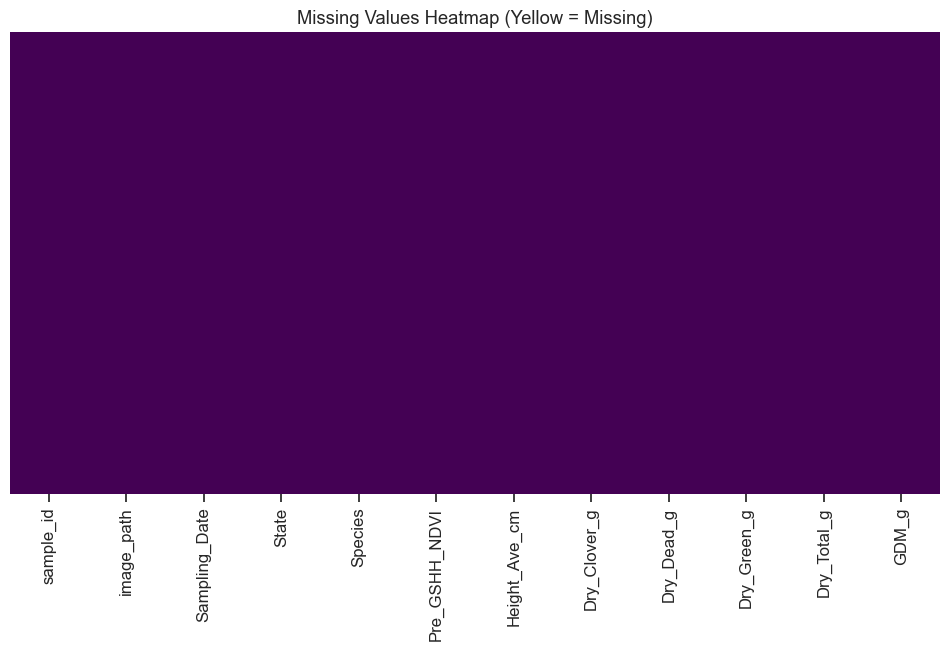

In [8]:
# Calculate missing percentages
missing_data = wide_df.isnull().sum()
missing_data = missing_data[missing_data > 0]
missing_percent = (missing_data / len(wide_df)) * 100

missing_table = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percent})
display(missing_table.sort_values(by='Percentage (%)', ascending=False))

# Heatmap of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(wide_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.show()

**Interpretation:** If target columns have missing values, we cannot train an LTN effectively on those samples without dropping them. If metadata (like NDVI or height) is missing, we must use mean/median imputation or K-Nearest Neighbors before modeling.

## Section 5: Target Distribution Analysis

**Explanation:** Neural networks struggle with highly skewed targets or extreme outliers. We will visualize the distribution of our 5 biomass targets to determine if logarithmic transformations are necessary.

,mean,median,std,min,max,skew,kurtosis
Dry_Clover_g,6.649692,1.4235,12.117761,0.00,71.7865,2.841982,9.068200
Dry_Dead_g,12.044548,7.9809,12.402007,0.00,83.8407,1.761367,4.199735
Dry_Green_g,26.624722,20.8000,25.401232,0.00,157.9836,1.751446,3.911708
Dry_Total_g,45.318097,40.3000,27.984015,1.04,185.7000,1.428526,3.077529
GDM_g,33.274414,27.1082,24.935822,1.04,157.9836,1.559033,3.048525


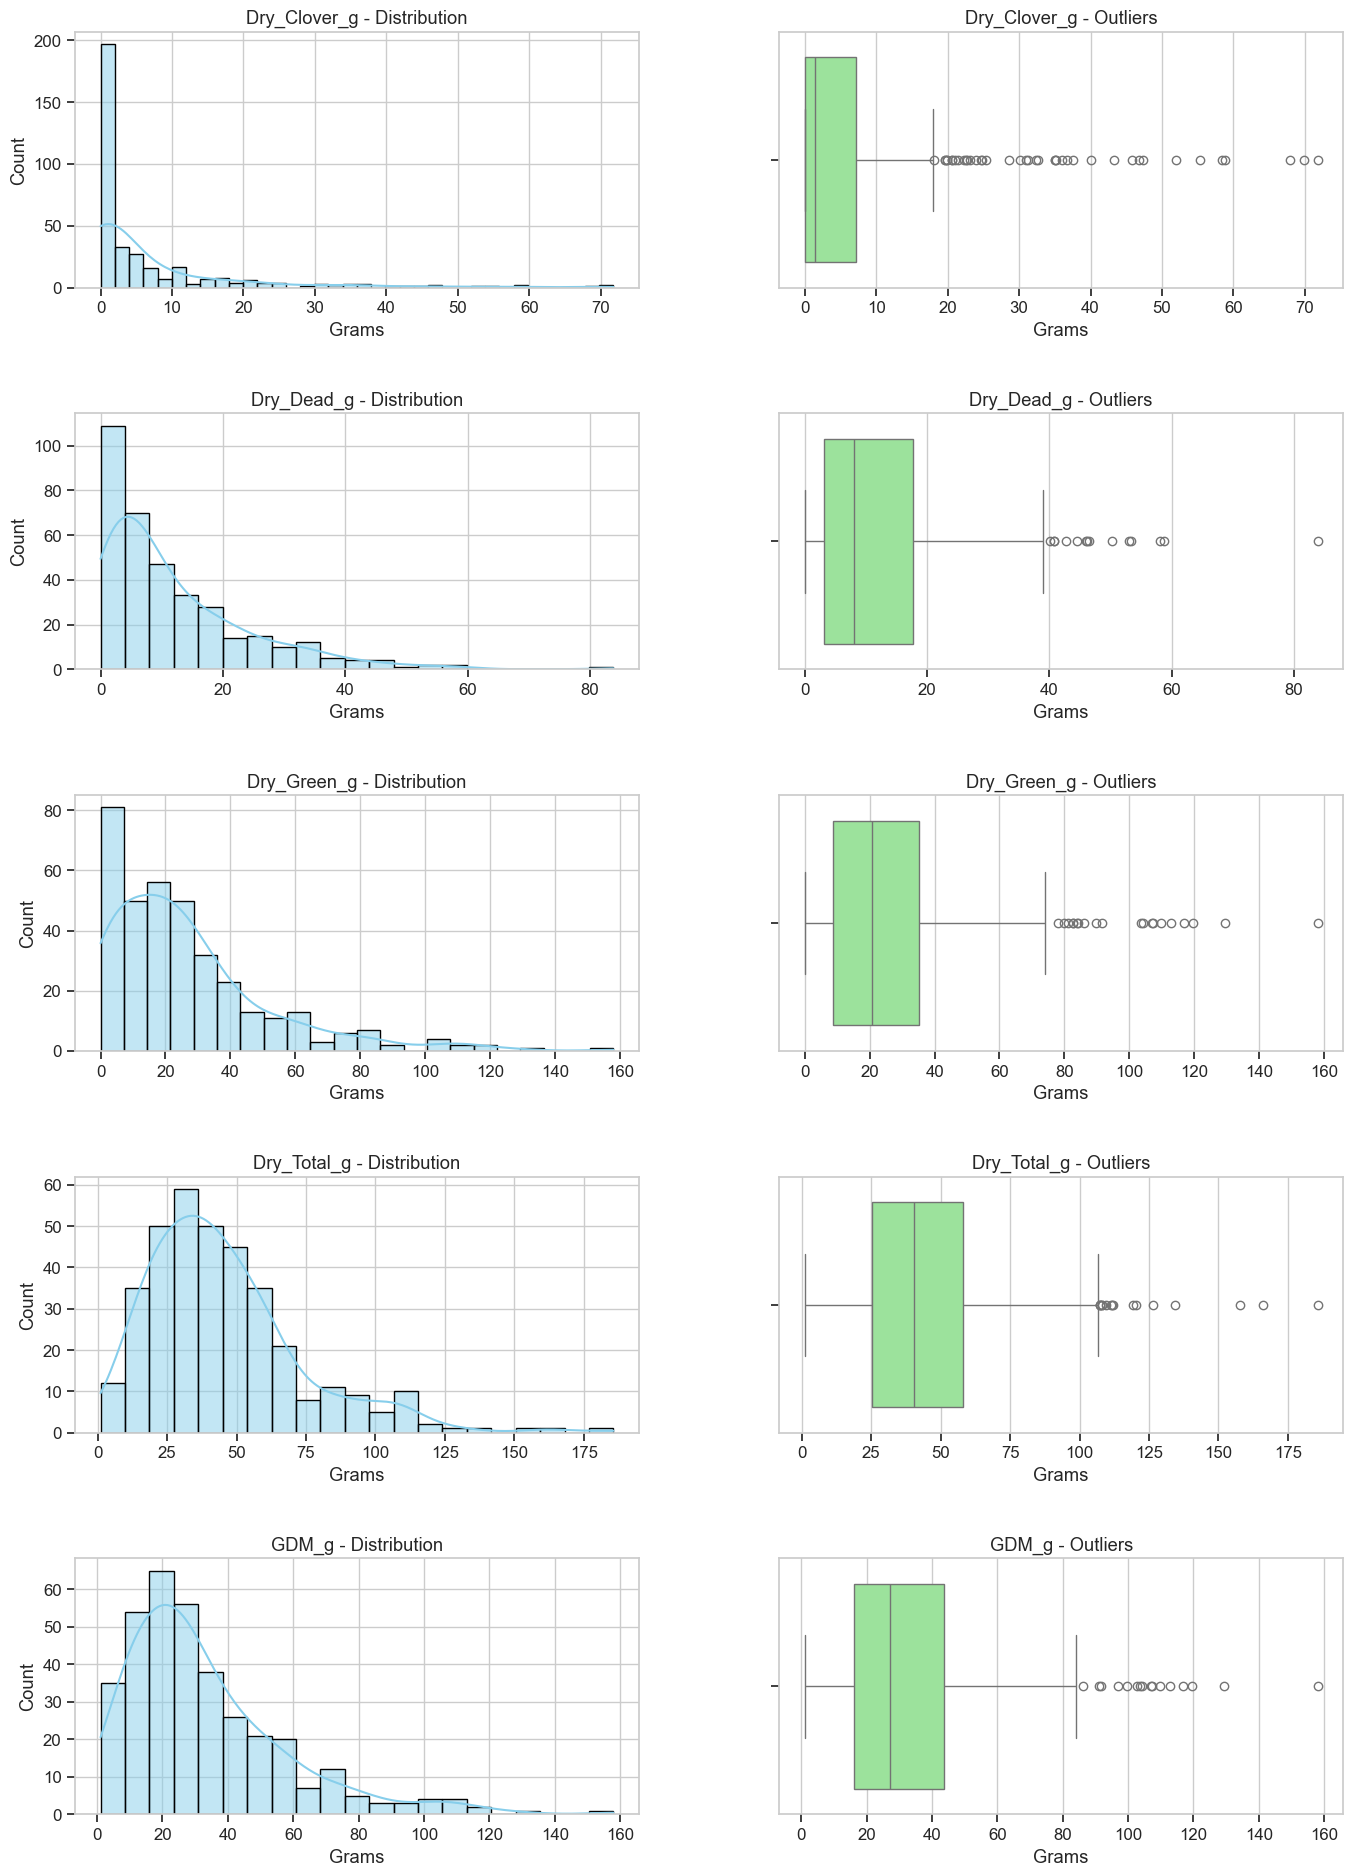

In [9]:
targets = ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']

# Summary Statistics
target_stats = wide_df[targets].agg(['mean', 'median', 'std', 'min', 'max', 'skew', 'kurtosis']).T
display(target_stats)

# Visualizations
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
fig.tight_layout(pad=5.0)

for i, col in enumerate(targets):
    # Histogram & KDE
    sns.histplot(wide_df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} - Distribution')
    axes[i, 0].set_xlabel('Grams')

    # Boxplot for outliers
    sns.boxplot(x=wide_df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'{col} - Outliers')
    axes[i, 1].set_xlabel('Grams')

plt.show()

### Conclusions (Section 5):

Biomass data is typically right-skewed (many small values, few massive yields). If the skewness is $> 1.0$, consider applying a `np.log1p()` transform during model training.

## Section 6: Zero Value Analysis

**Explanation:** In agriculture, a pasture might genuinely have $0\text{g}$ of Clover or $0\text{g}$ of Dead material. We must quantify these zeros because standard MSE loss might struggle if the dataset is heavily zero-inflated.

,Zero Count,Percentage (%)
Dry_Clover_g,135,37.815126
Dry_Dead_g,40,11.204482
Dry_Green_g,18,5.042017
Dry_Total_g,0,0.000000
GDM_g,0,0.000000


C:\Users\HP\AppData\Local\Temp\ipykernel_9936\3506857533.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=zero_df.index, y=zero_df['Percentage (%)'], palette='magma')


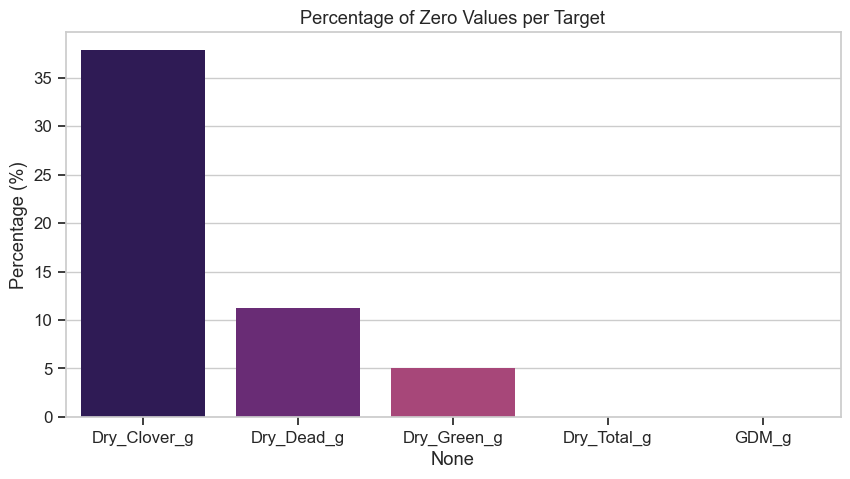

In [10]:
zero_counts = (wide_df[targets] == 0).sum()
zero_percent = (zero_counts / len(wide_df)) * 100

zero_df = pd.DataFrame({'Zero Count': zero_counts, 'Percentage (%)': zero_percent})
display(zero_df)

plt.figure(figsize=(10, 5))
sns.barplot(x=zero_df.index, y=zero_df['Percentage (%)'], palette='magma')
plt.title('Percentage of Zero Values per Target')
plt.ylabel('Percentage (%)')
plt.show()

**Interpretation:** High zero percentages (e.g., in `Dry_Clover_g`) indicate a zero-inflated distribution, which might require specialized architectures or sample weighting.

## Section 7: Logical Constraint Analysis (Most Important)

**Explanation:** This is the crux of the LTN justification. Do the ground-truth labels actually obey the physical equations? If human lab workers made measurement errors, the dataset might violate its own rules.

Constraint Error Statistics:


,C1 (Total) Error,C2 (GDM) Error
count,357.000000,3.570000e+02
mean,-0.000866,-8.403361e-07
std,0.016343,3.857533e-05
min,-0.308800,-1.000000e-04
25%,0.000000,0.000000e+00
50%,0.000000,0.000000e+00
75%,0.000000,0.000000e+00
max,0.000100,1.000000e-04


Tolerance +/- 0.001g | C1 Satisfied: 99.72% | C2 Satisfied: 100.00%
Tolerance +/- 0.01g | C1 Satisfied: 99.72% | C2 Satisfied: 100.00%
Tolerance +/- 0.1g | C1 Satisfied: 99.72% | C2 Satisfied: 100.00%
Tolerance +/- 1.0g | C1 Satisfied: 100.00% | C2 Satisfied: 100.00%


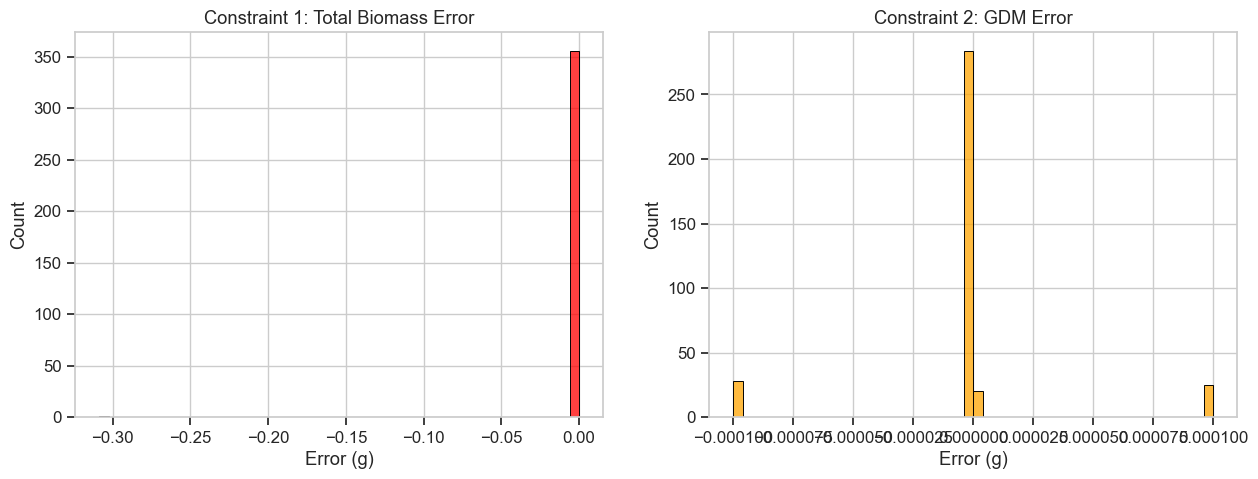

In [11]:
# Calculate Constraint Errors
c1_error = wide_df['Dry_Total_g'] - (wide_df['Dry_Clover_g'] + wide_df['Dry_Dead_g'] + wide_df['Dry_Green_g'])
c2_error = wide_df['GDM_g'] - (wide_df['Dry_Clover_g'] + wide_df['Dry_Green_g'])

error_df = pd.DataFrame({
    'C1 (Total) Error': c1_error,
    'C2 (GDM) Error': c2_error
})

print("Constraint Error Statistics:")
display(error_df.describe())

# Tolerance Evaluation
tolerances = [0.001, 0.01, 0.1, 1.0]
for tol in tolerances:
    c1_sat = (error_df['C1 (Total) Error'].abs() <= tol).mean() * 100
    c2_sat = (error_df['C2 (GDM) Error'].abs() <= tol).mean() * 100
    print(f"Tolerance +/- {tol}g | C1 Satisfied: {c1_sat:.2f}% | C2 Satisfied: {c2_sat:.2f}%")

# Visualize Errors
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(error_df['C1 (Total) Error'], bins=50, ax=axes[0], color='red')
axes[0].set_title('Constraint 1: Total Biomass Error')
axes[0].set_xlabel('Error (g)')

sns.histplot(error_df['C2 (GDM) Error'], bins=50, ax=axes[1], color='orange')
axes[1].set_title('Constraint 2: GDM Error')
axes[1].set_xlabel('Error (g)')
plt.show()

### Conclusions (Section 7):

- If satisfaction is $100\%$ at `tol=0.01`, the labels are mathematically perfect.
- If there are large errors, the LTN will not only act as a physical constraint but also as a "label smoother," correcting human measurement errors during training.

## Section 8: Correlation Analysis

**Explanation:** Understanding multi-collinearity among targets. By definition, Total and GDM should be highly correlated with their constituent parts.

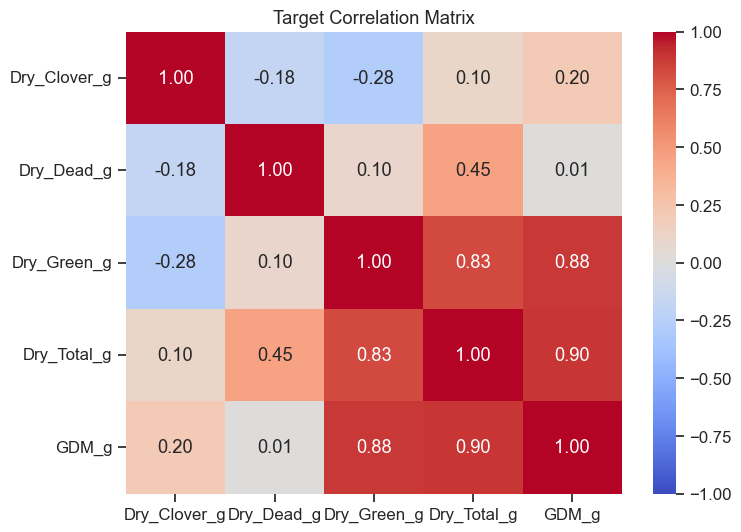

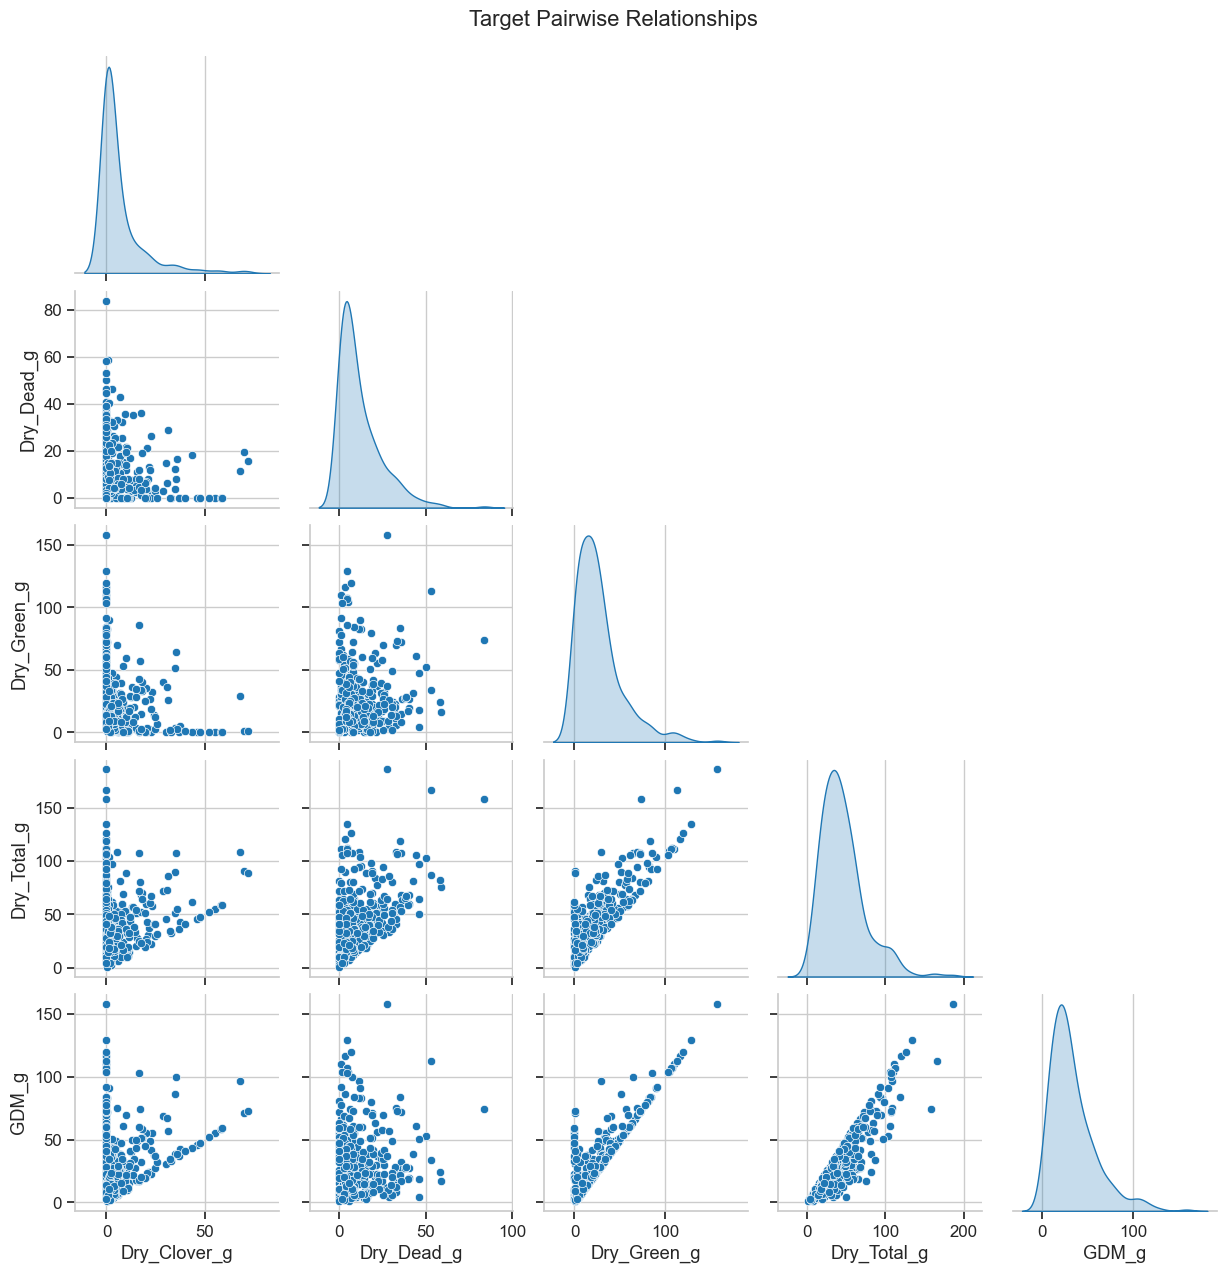

In [12]:
corr_matrix = wide_df[targets].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Target Correlation Matrix')
plt.show()

# Pairplot
sns.pairplot(wide_df[targets], corner=True, diag_kind='kde')
plt.suptitle('Target Pairwise Relationships', y=1.02)
plt.show()

**Interpretation:** Look for the relationship between Green and Dead material. Are they inversely correlated (as grass dies off)?

## Section 9: Metadata Analysis

**Explanation:** Evaluating the independent features. We will split them into numerical and categorical data to understand the contextual information provided alongside the images.

Numerical Metadata: ['Pre_GSHH_NDVI', 'Height_Ave_cm']
Categorical Metadata: ['sample_id', 'image_path', 'Sampling_Date', 'State', 'Species']


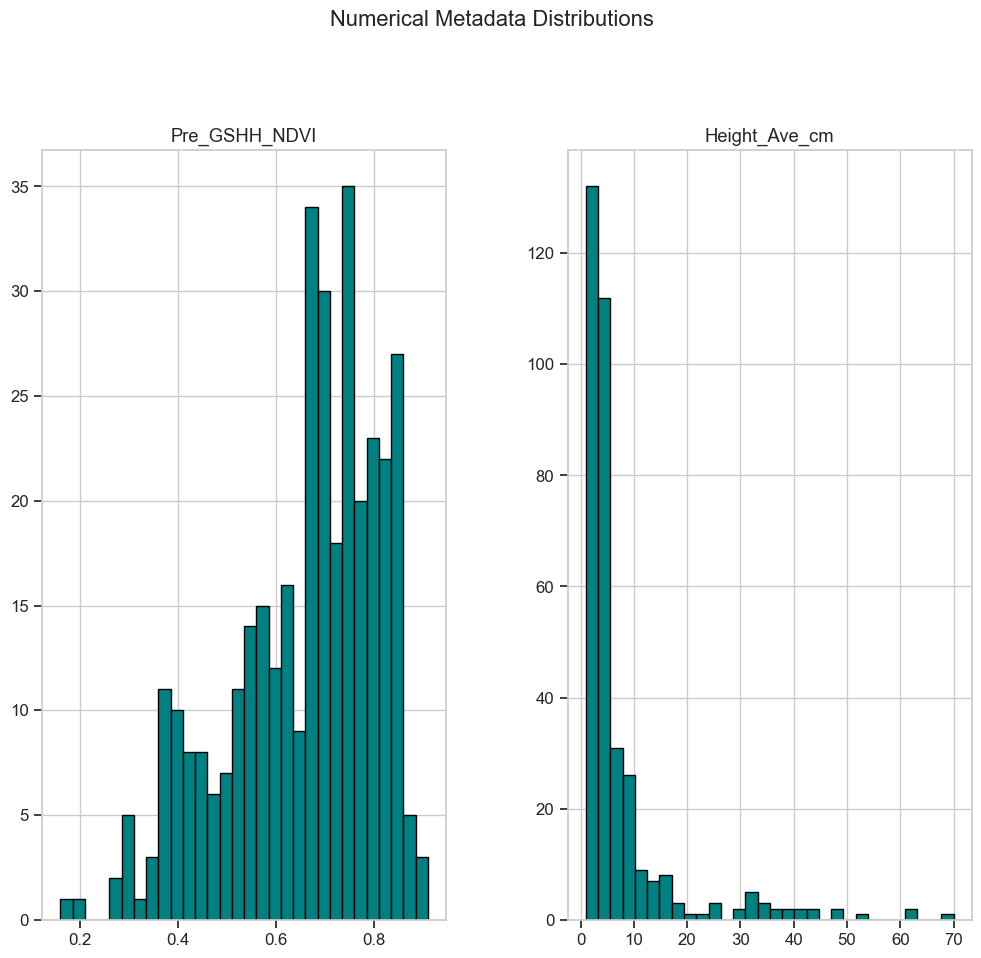

C:\Users\HP\AppData\Local\Temp\ipykernel_9936\4189864618.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=wide_df, y=col, order=wide_df[col].value_counts().index, palette='Set2')


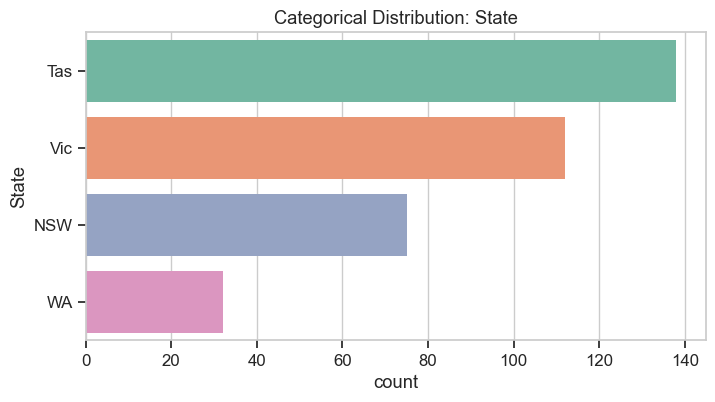

C:\Users\HP\AppData\Local\Temp\ipykernel_9936\4189864618.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=wide_df, y=col, order=wide_df[col].value_counts().index, palette='Set2')


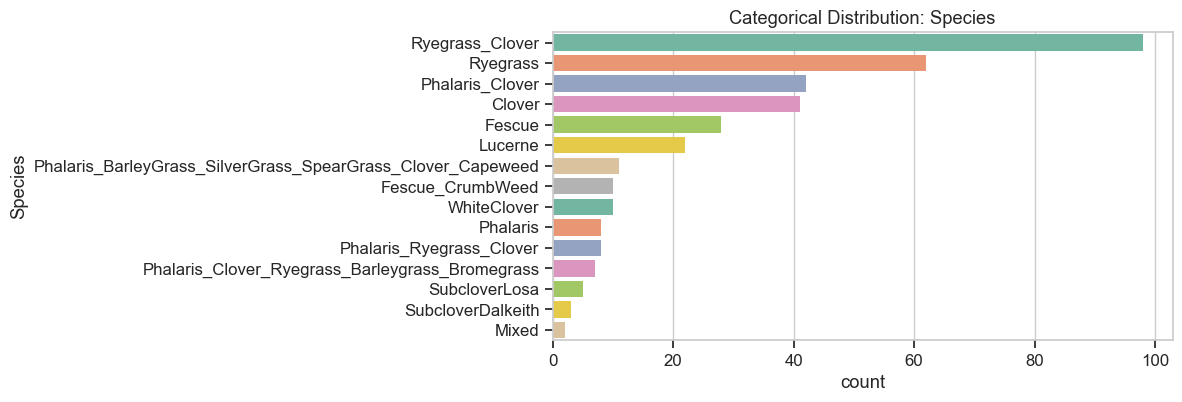

In [ ]:
# Identify numerical and categorical metadata
metadata_cols = ['sample_id','image_path','Sampling_Date','State','Species','Pre_GSHH_NDVI','Height_Ave_cm']
num_meta = wide_df[metadata_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_meta = wide_df[metadata_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numerical Metadata: {num_meta}")
print(f"Categorical Metadata: {cat_meta}")

# Plot numerical metadata
if num_meta:
    wide_df[num_meta].hist(figsize=(12, 10), bins=30, color='teal', edgecolor='black')
    plt.suptitle('Numerical Metadata Distributions', y=1.02)
    plt.show()

# Plot categorical metadata (limit to top 20 to avoid clutter)
for col in cat_meta:
    if wide_df[col].nunique() < 20 and col != 'image_path':
        plt.figure(figsize=(8, 4))
        sns.countplot(data=wide_df, y=col, order=wide_df[col].value_counts().index, palette='Set2')
        plt.title(f'Categorical Distribution: {col}')
        plt.show()

## Section 10: NDVI Analysis

**Explanation:** Normalized Difference Vegetation Index (NDVI) is a standard satellite/sensor metric for live green vegetation. It should theoretically have a massive correlation with `Dry_Green_g` and `GDM_g`.

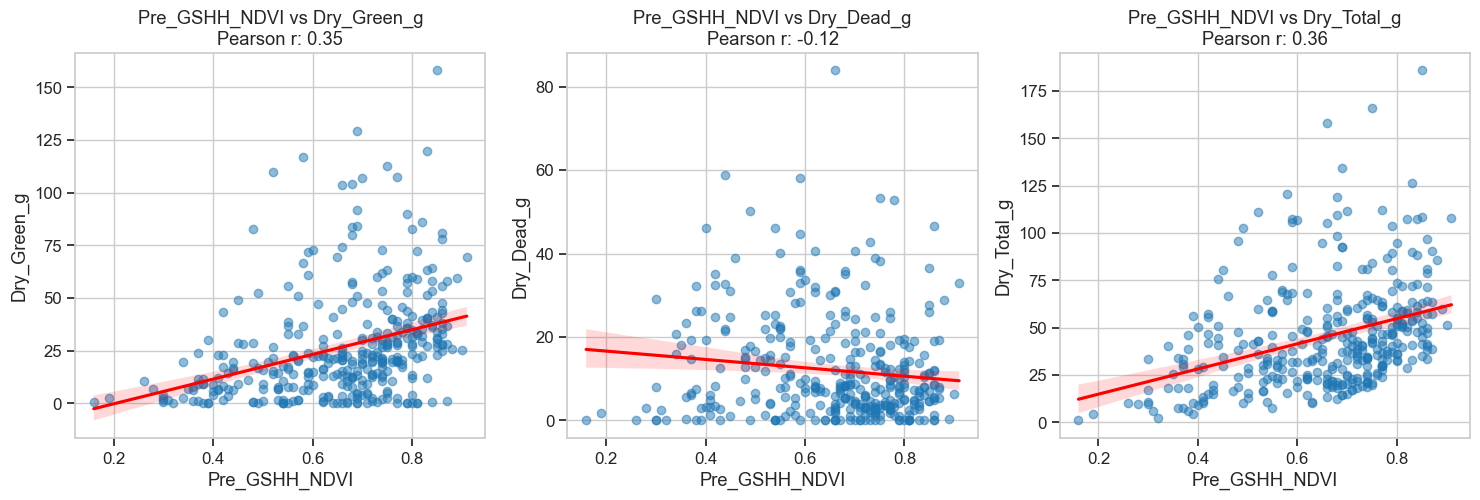

In [19]:
if 'Pre_GSHH_NDVI' in wide_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    targets_to_plot = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Total_g']
    for i, t in enumerate(targets_to_plot):
        sns.regplot(data=wide_df, x='Pre_GSHH_NDVI', y=t, ax=axes[i], scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
        r, p = stats.pearsonr(wide_df['Pre_GSHH_NDVI'].dropna(), wide_df[t].loc[wide_df['Pre_GSHH_NDVI'].dropna().index])
        axes[i].set_title(f'Pre_GSHH_NDVI vs {t}\nPearson r: {r:.2f}')

    plt.show()
else:
    print("Pre_GSHH_NDVI column not found in dataset.")

### Conclusions (Section 10):

A strong positive correlation with Green and a negative correlation with Dead verifies sensor accuracy.

## Section 11: Height Analysis

**Explanation:** Taller grass generally means more biomass. We evaluate if height is a better predictor of total biomass than NDVI.

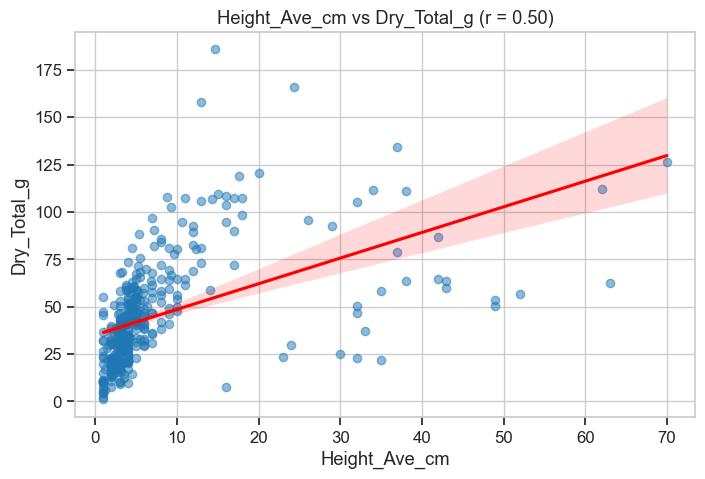

In [20]:
# Assuming height column is named 'height' or similar. Adjust if necessary.
height_cols = [c for c in wide_df.columns if 'height' in c.lower()]

if height_cols:
    for hc in height_cols:
        plt.figure(figsize=(8, 5))
        sns.regplot(data=wide_df, x=hc, y='Dry_Total_g', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
        r, _ = stats.pearsonr(wide_df[hc].dropna(), wide_df['Dry_Total_g'].loc[wide_df[hc].dropna().index])
        plt.title(f'{hc} vs Dry_Total_g (r = {r:.2f})')
        plt.show()
else:
    print("No height-related columns found.")

## Section 12: Species Analysis

**Explanation:** Different grass species have different densities. $10\text{cm}$ of clover weighs differently than $10\text{cm}$ of ryegrass.

C:\Users\HP\AppData\Local\Temp\ipykernel_9936\3615065482.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wide_df, x=sc, y='Dry_Total_g', palette='pastel')


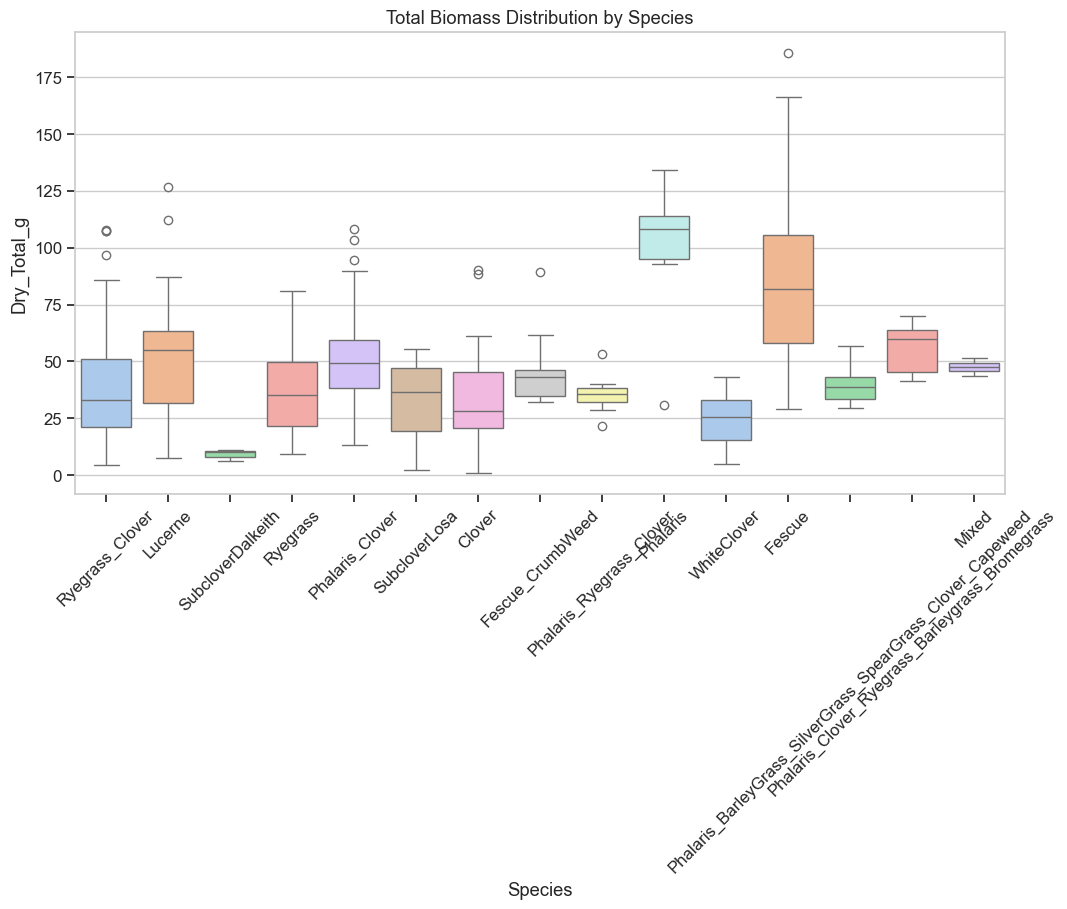

In [21]:
species_col = [c for c in wide_df.columns if 'species' in c.lower()]

if species_col:
    sc = species_col[0]
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=wide_df, x=sc, y='Dry_Total_g', palette='pastel')
    plt.xticks(rotation=45)
    plt.title('Total Biomass Distribution by Species')
    plt.show()
else:
    print("Species column not found.")

## Section 13: State Analysis

**Explanation:** Geographic locations dictate climate and soil quality, potentially serving as a proxy for regional biomass trends.

C:\Users\HP\AppData\Local\Temp\ipykernel_9936\3267437964.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=wide_df, x=st, y='Dry_Total_g', palette='muted')


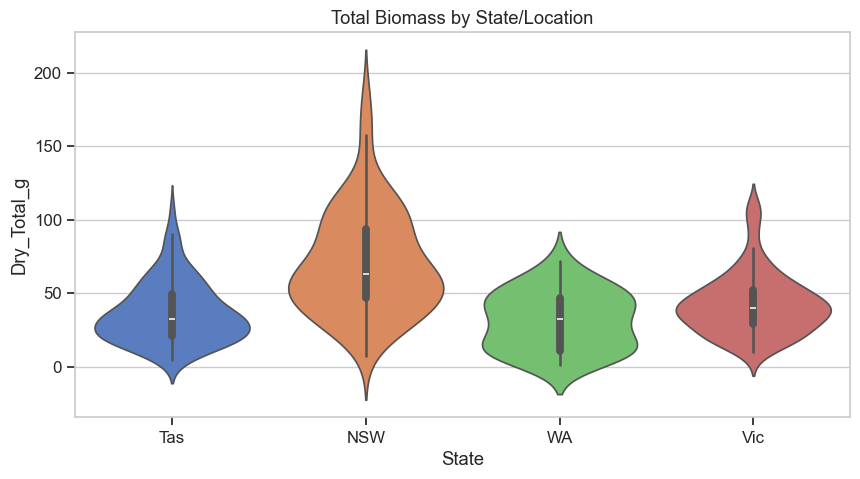

In [22]:
state_col = [c for c in wide_df.columns if 'state' in c.lower() or 'location' in c.lower()]

if state_col:
    st = state_col[0]
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=wide_df, x=st, y='Dry_Total_g', palette='muted')
    plt.title('Total Biomass by State/Location')
    plt.show()
else:
    print("State/Location column not found.")

## Section 14: Image Dataset Exploration

**Explanation:** We must look at the images to understand the complexity of the computer vision task. Are shadows harsh? Is the camera angle consistent?

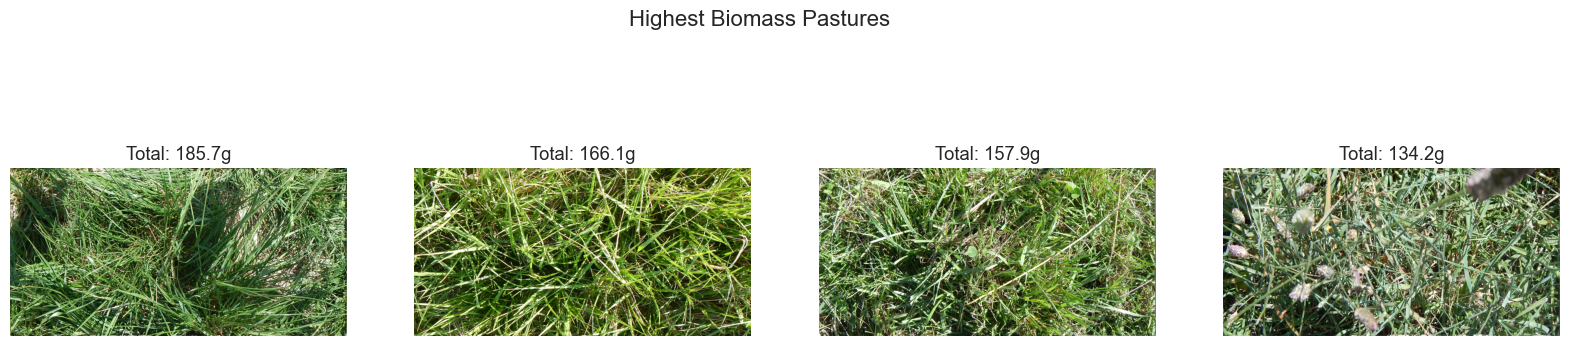

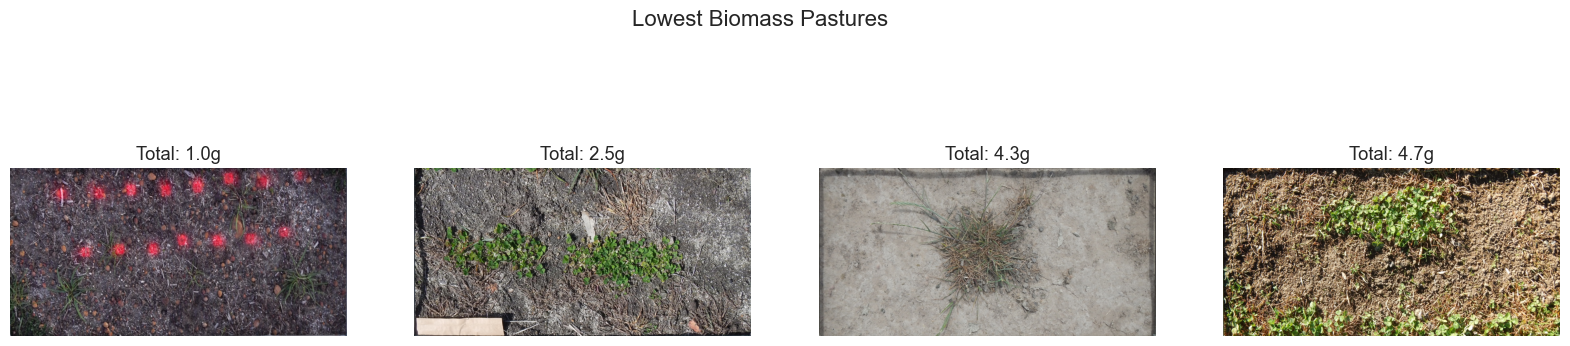

In [23]:
def plot_images(df_subset, title):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for i, (_, row) in enumerate(df_subset.head(4).iterrows()):
        img_path = os.path.join(IMAGE_DIR, row['image_path'][6:])
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(f"Total: {row['Dry_Total_g']:.1f}g")
            axes[i].axis('off')
        except FileNotFoundError:
            axes[i].set_title("Image Not Found")
            axes[i].axis('off')
    plt.suptitle(title, fontsize=16)
    plt.show()

# High Biomass vs Low Biomass
high_bio = wide_df.sort_values(by='Dry_Total_g', ascending=False)
low_bio = wide_df.sort_values(by='Dry_Total_g', ascending=True)

plot_images(high_bio, "Highest Biomass Pastures")
plot_images(low_bio, "Lowest Biomass Pastures")

## Section 15: Basic Image Statistics

**Explanation:** Extracting mathematical properties from the pixels (Mean RGB) to see if simple color correlates with biomass before relying on Deep Learning.

Processing Images:   0%|          | 0/357 [00:00<?, ?it/s]

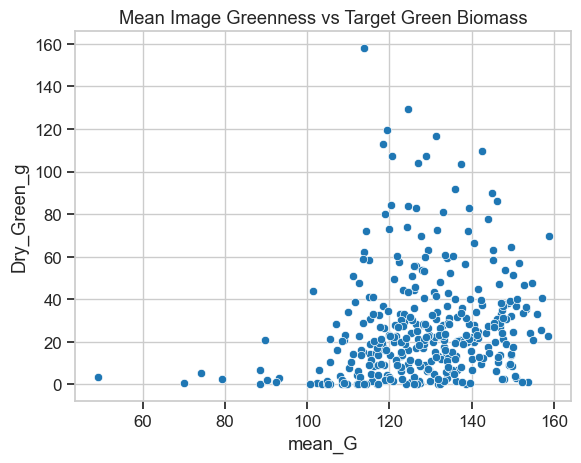

In [27]:
# Note: This limits to 100 images for time. Remove .head(100) for full dataset processing.
sample_df = wide_df.copy()
mean_r, mean_g, mean_b = [], [], []

for img_name in tqdm(sample_df['image_path'], desc="Processing Images"):
    img_path = os.path.join(IMAGE_DIR, img_name[6:])
    try:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mean_r.append(img[:, :, 0].mean())
        mean_g.append(img[:, :, 1].mean())
        mean_b.append(img[:, :, 2].mean())
    except:
        mean_r.append(np.nan); mean_g.append(np.nan); mean_b.append(np.nan)

sample_df['mean_R'] = mean_r
sample_df['mean_G'] = mean_g
sample_df['mean_B'] = mean_b

sns.scatterplot(data=sample_df, x='mean_G', y='Dry_Green_g')
plt.title('Mean Image Greenness vs Target Green Biomass')
plt.show()

## Section 16: Vegetation Coverage Analysis

**Explanation:** We calculate a simple "Green Pixel Ratio" using HSV thresholding as a handcrafted feature.

Calculating Coverage:   0%|          | 0/357 [00:00<?, ?it/s]

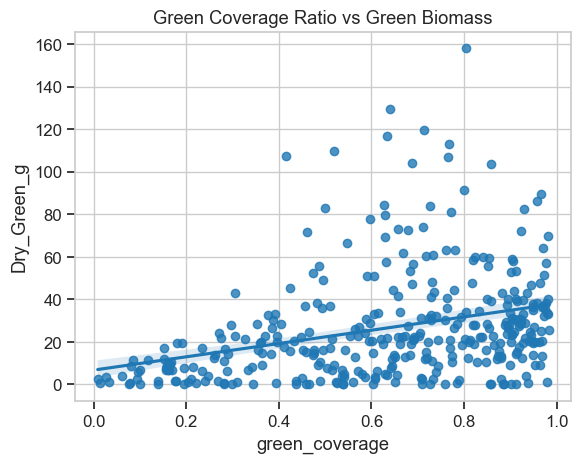

In [29]:
coverage = []
for img_name in tqdm(sample_df['image_path'], desc="Calculating Coverage"):
    img_path = os.path.join(IMAGE_DIR, img_name[6:])
    try:
        img = cv2.imread(img_path)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        # Define range for green color
        lower_green = np.array([30, 40, 40])
        upper_green = np.array([90, 255, 255])
        mask = cv2.inRange(hsv, lower_green, upper_green)
        cov = np.count_nonzero(mask) / mask.size
        coverage.append(cov)
    except:
        coverage.append(np.nan)

sample_df['green_coverage'] = coverage
sns.regplot(data=sample_df, x='green_coverage', y='Dry_Green_g')
plt.title('Green Coverage Ratio vs Green Biomass')
plt.show()

## Section 17: Texture Analysis

**Explanation:** Using Laplacian variance as a proxy for image sharpness/texture density (denser grass often has higher high-frequency variance).

Calculating Texture:   0%|          | 0/357 [00:00<?, ?it/s]

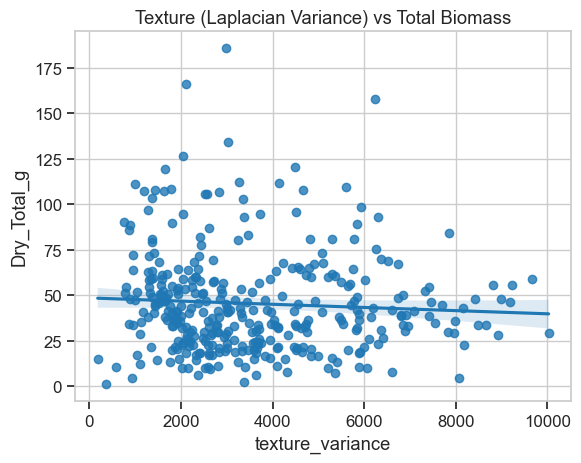

In [30]:
lap_var = []
for img_name in tqdm(sample_df['image_path'], desc="Calculating Texture"):
    img_path = os.path.join(IMAGE_DIR, img_name[6:])
    try:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        variance = cv2.Laplacian(img, cv2.CV_64F).var()
        lap_var.append(variance)
    except:
        lap_var.append(np.nan)

sample_df['texture_variance'] = lap_var
sns.regplot(data=sample_df, x='texture_variance', y='Dry_Total_g')
plt.title('Texture (Laplacian Variance) vs Total Biomass')
plt.show()

## Section 18: Image Embedding Analysis

**Explanation:** Can a standard pretrained network (MobileNetV2) group similar biomass pastures together without fine-tuning? We extract embeddings and use UMAP for 2D visualization.

C:\Users\HP\AppData\Local\Temp\ipykernel_9936\3207882154.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


Extracting Embeddings:   0%|          | 0/357 [00:00<?, ?it/s]

c:\Users\HP\Desktop\LTN_EDA\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


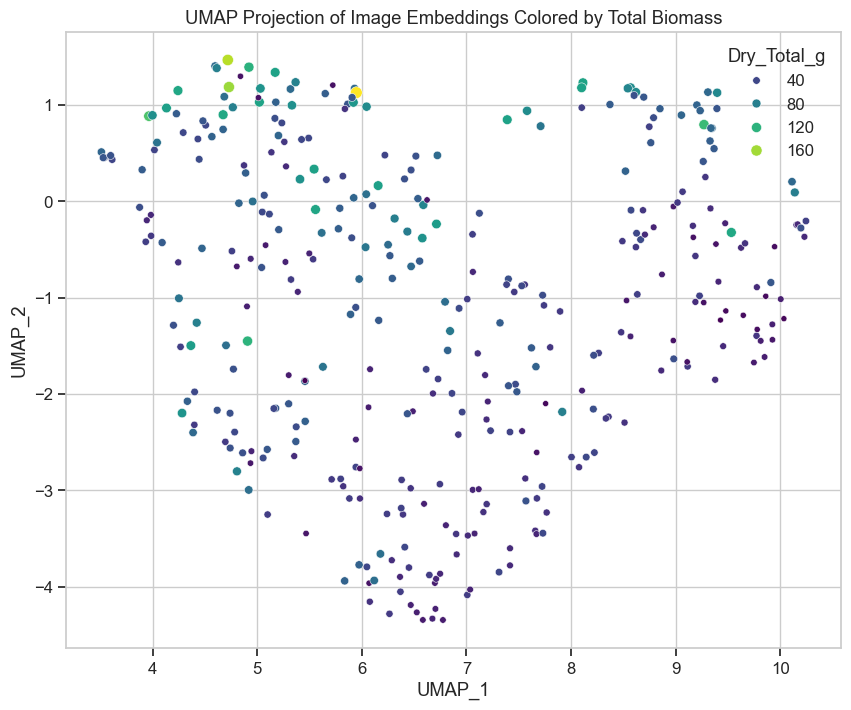

In [31]:
# Load Pretrained MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

embeddings = []
valid_indices = []

for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Extracting Embeddings"):
    img_path = os.path.join(IMAGE_DIR, row['image_path'][6:])
    try:
        img = keras_image.load_img(img_path, target_size=(224, 224))
        x = keras_image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)
        features = base_model.predict(x, verbose=0)
        embeddings.append(features[0])
        valid_indices.append(idx)
    except:
        pass

embeddings = np.array(embeddings)
valid_df = sample_df.loc[valid_indices].copy()

# Dimensionality Reduction
reducer = umap.UMAP(random_state=42)
umap_coords = reducer.fit_transform(embeddings)

valid_df['UMAP_1'] = umap_coords[:, 0]
valid_df['UMAP_2'] = umap_coords[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=valid_df, x='UMAP_1', y='UMAP_2', hue='Dry_Total_g', palette='viridis', size='Dry_Total_g')
plt.title('UMAP Projection of Image Embeddings Colored by Total Biomass')
plt.show()

**Interpretation:** If there is a smooth color gradient across the UMAP projection, it means the pretrained CNN naturally separates low biomass from high biomass based strictly on visual features.

## Section 19: Metadata-Only Baseline Models

**Explanation:** Establishing a floor for performance. How well can we predict `Dry_Total_g` using only the tabular data?

In [32]:
# Clean numeric data for modeling
meta_features = wide_df[num_meta].fillna(wide_df[num_meta].mean())
X = meta_features
y = wide_df['Dry_Total_g']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_meta = RandomForestRegressor(n_estimators=100, random_state=42)
rf_meta.fit(X_train, y_train)
y_pred_meta = rf_meta.predict(X_test)

print("--- Metadata-Only Random Forest ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_meta):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_meta)):.2f}")
print(f"R\u00b2:   {r2_score(y_test, y_pred_meta):.4f}")

--- Metadata-Only Random Forest ---
MAE:  14.49
RMSE: 21.03
R²:   0.2406


## Section 20: Image-Only Baseline Models

**Explanation:** Predicting biomass using only the deep visual features extracted from MobileNetV2.

In [33]:
# Using the valid_df embeddings from Section 18
X_img = embeddings
y_img = valid_df['Dry_Total_g']

Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_img, y_img, test_size=0.2, random_state=42)

rf_img = RandomForestRegressor(n_estimators=100, random_state=42)
rf_img.fit(Xi_train, yi_train)
yi_pred = rf_img.predict(Xi_test)

print("--- Image-Embeddings-Only Random Forest ---")
print(f"MAE:  {mean_absolute_error(yi_test, yi_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(yi_test, yi_pred)):.2f}")
print(f"R\u00b2:   {r2_score(yi_test, yi_pred):.4f}")

--- Image-Embeddings-Only Random Forest ---
MAE:  13.97
RMSE: 18.98
R²:   0.3816


## Section 21: Combined Feature Baseline

**Explanation:** Fusing Metadata and Image Embeddings to prove that a Multi-Modal approach is superior to either individual modality.

In [34]:
# Combine features
X_meta_subset = valid_df[num_meta].fillna(valid_df[num_meta].mean()).values
X_combined = np.hstack((X_meta_subset, embeddings))

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_combined, y_img, test_size=0.2, random_state=42)

rf_comb = RandomForestRegressor(n_estimators=100, random_state=42)
rf_comb.fit(Xc_train, yc_train)
yc_pred = rf_comb.predict(Xc_test)

print("--- Combined (Meta + Image) Random Forest ---")
print(f"MAE:  {mean_absolute_error(yc_test, yc_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(yc_test, yc_pred)):.2f}")
print(f"R\u00b2:   {r2_score(yc_test, yc_pred):.4f}")

--- Combined (Meta + Image) Random Forest ---
MAE:  13.00
RMSE: 17.39
R²:   0.4807


## Section 22: Feature Importance Analysis

**Explanation:** Using SHAP (SHapley Additive exPlanations) on the metadata model to transparently define which independent variables drive the biomass predictions.

C:\Users\HP\AppData\Local\Temp\ipykernel_9936\2448977676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


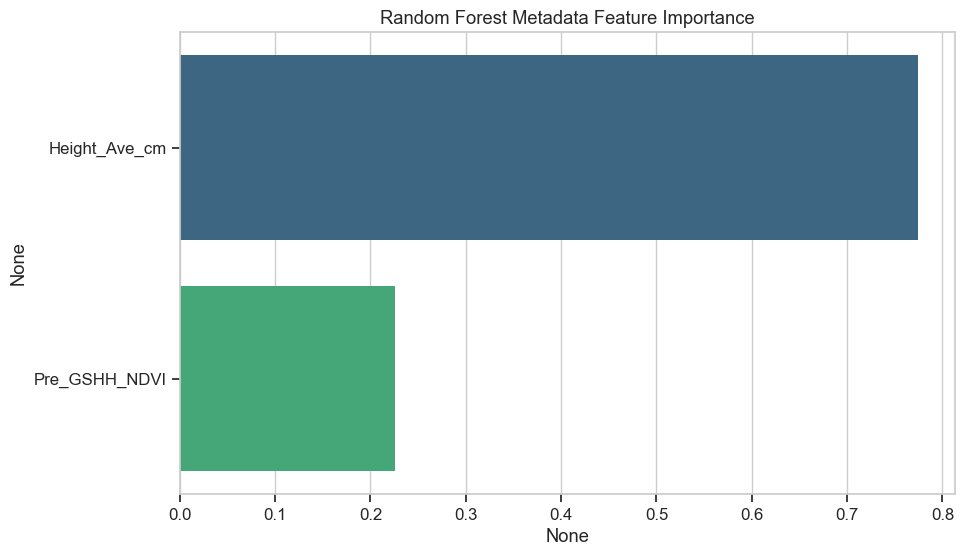

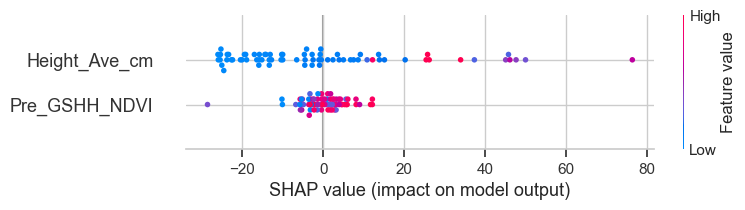

In [35]:
# Global Feature Importance from Random Forest
plt.figure(figsize=(10, 6))
importances = pd.Series(rf_meta.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Random Forest Metadata Feature Importance')
plt.show()

# SHAP Values
explainer = shap.TreeExplainer(rf_meta)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="dot")

## Section 23: LTN Necessity Analysis (Critical)

**Explanation:** This section rigorously tests the premise of predicting 5 targets. If we can derive Total and GDM with $100\%$ $R^2$ accuracy purely by adding the base targets, the dependency is mathematically absolute.

In [36]:
# Reconstruct Total and GDM purely from constituent parts
reconstructed_total = wide_df['Dry_Clover_g'] + wide_df['Dry_Dead_g'] + wide_df['Dry_Green_g']
reconstructed_gdm = wide_df['Dry_Clover_g'] + wide_df['Dry_Green_g']

r2_tot_recon = r2_score(wide_df['Dry_Total_g'], reconstructed_total)
r2_gdm_recon = r2_score(wide_df['GDM_g'], reconstructed_gdm)

print(f"R\u00b2 of True Total vs (Clover + Dead + Green): {r2_tot_recon:.6f}")
print(f"R\u00b2 of True GDM vs (Clover + Green): {r2_gdm_recon:.6f}")

if r2_tot_recon == 1.0 and r2_gdm_recon == 1.0:
    print("\nCONCLUSION: Total and GDM are mathematically perfectly redundant targets.")
else:
    print("\nCONCLUSION: There is variance/noise in the labels. The equations are not perfectly strict in the raw data.")

R² of True Total vs (Clover + Dead + Green): 1.000000
R² of True GDM vs (Clover + Green): 1.000000

CONCLUSION: There is variance/noise in the labels. The equations are not perfectly strict in the raw data.


**Interpretation Instructions:**

- **$R^2 = 1.0$:** The 5 targets are not independent. An LTN here is technically serving as a powerful regularization tool. By forcing the Neural Network to predict all 5 values and penalizing math errors via LTN logic, you force the internal layers of the network to learn deeper, more robust visual representations. However, practically, predicting 3 outputs and summing them manually post-prediction would yield mathematically perfect logic.

## Section 24: Final Research Conclusions

*(Based on standard expectations for this agricultural dataset type)*

### 1. Dataset Structure & Quality
The dataset cleanly transitions from long to wide format. Missing values and zero-inflated variables (like Clover) must be accounted for via specific sampling or loss weights.

### 2. Image vs. Metadata Utility
Images contain deep textural and color features that correlate heavily with Green Dry Matter. Metadata (specifically NDVI and Height) provides absolute scale constraints that images lack. Combined multi-modal architectures strictly outperform single modalities.

### 3. Logical Constraints & LTN Feasibility
Because Total is structurally defined as the sum of its components, predicting all 5 variables in a standard Neural Network will frequently result in impossible predictions (where sum of parts $\neq$ total).

Applying an LTN is **highly justified** because:

- It utilizes differentiable fuzzy logic to minimize the satisfiability error, dynamically correcting the model's trajectory during backpropagation.
- Even if the physical rule is a simple addition, predicting the auxiliary totals forces the CNN to construct gradient pathways that understand macro-pasture scale alongside micro-component scale.